In [1]:
from matplotlib.ticker import LinearLocator
import numpy as np
import matplotlib.pyplot as plt
from jax import vmap
import jax.numpy as jnp
from functools import partial
import sys
import jax

jax.config.update("jax_platform_name", "cpu")


sys.path.append("..")

In [2]:
from configuration.rte2d_settings import get_config

# from utils.integrate import leggauss
from utils.coord_generator import cartesian_product

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
print(f"domian: {domain}")
kn = 0.1  # rte_config.model.knudsen_number
num_quads = rte_config.model.num_quads
fn_sigma_s = rte_config.model.coeff["scattering"]
fn_sigma_a = rte_config.model.coeff["absorption"]
fn_l = rte_config.model.bdy_cond["f_l"]
fn_r = rte_config.model.bdy_cond["f_r"]
fn_b = rte_config.model.bdy_cond["f_b"]
fn_t = rte_config.model.bdy_cond["f_t"]
source_fn = rte_config.model.source

num_x, num_y, num_theta = rte_config.model.grid_sizes
print(f"num_x: {num_x}, num_y: {num_y}, num_theta: {num_theta}")

(xmin, xmax), (vmin, vmax), (theta_min, theta_max) = (
    domain["x"],
    domain["y"],
    domain["theta"],
)
dx = (xmax - xmin) / num_x
dy = (vmax - vmin) / num_y
dtheta = (theta_max - theta_min) / num_theta
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin + dx / 2, xmax - dx / 2, num_x
)  # num_x pts in cell center (not include gohst points)
mesh_y = np.linspace(vmin, vmax, num_y + 1)
mesh_yc = np.linspace(
    vmin + dy / 2, vmax - dy / 2, num_y
)  # num_x pts in cell center (not include gohst points)
mesh_theta = np.linspace(theta_min, theta_max, num_theta * 4)
cos_dx = (np.cos(mesh_theta) / dx)[None, None, :]  # (1, 1, num_theta)
sin_dy = (np.sin(mesh_theta) / dy)[None, None, :]  # (1, 1, num_theta)

domian: {'hole': x: &id001 !!python/tuple
- -0.3333333333333333
- 0.3333333333333333
y: *id001
, 'theta': (0.0, 6.283185307179586), 'x': (-1, 1), 'y': (-1, 1)}
num_x: 64, num_y: 64, num_theta: 32


In [4]:
# compute the scattering and absorption coefficient at each cell center
mesh_xyc = cartesian_product([mesh_xc[:, None], mesh_yc[:, None]])  # (num_x, num_y, 2)
X, Y = [d.squeeze() for d in jnp.split(mesh_xyc, 2, axis=-1)]  # (num_x, num_y)
# mat_fn_sigma_s = vmap(fn_sigma_s, in_axes=(0, 0))(
#     X.reshape(-1), Y.reshape(-1)
# ).reshape(num_x, num_y)  # (num_x, num_y)
mat_fn_sigma_s = vmap(vmap(fn_sigma_s, in_axes=(0, 0)), in_axes=(0, 0))(
    X, Y
)  # (num_x, num_y)
mat_fn_sigma_a = vmap(vmap(fn_sigma_a, in_axes=(0, 0)), in_axes=(0, 0))(X, Y)
tensor_fn_sigma_s = np.asarray(mat_fn_sigma_s)[..., None]
tensor_fn_sigma_a = np.asarray(mat_fn_sigma_a)[..., None]
tensor_fn_sigma_t = tensor_fn_sigma_s + tensor_fn_sigma_a * kn**2  # (num_x, num_y, 1)

tensor_fn_sigma_s.shape, mesh_xyc.shape

((64, 64, 1), (64, 64, 2))

In [5]:
weights = 2.0 * np.pi / (num_theta * 4 - 1) * np.ones(num_theta * 4)
weights[0] *= 0.5
weights[-1] *= 0.5

In [6]:
# compute the source term at each cell center and each angle
mesh_xyc_theta = cartesian_product([
    mesh_xc[:, None],
    mesh_yc[:, None],
    mesh_theta[:, None],
])
X, Y, Theta = [
    d.squeeze() for d in jnp.split(mesh_xyc_theta, 3, axis=-1)
]  # (num_x, num_y, num_theta)

tensor_source = vmap(
    vmap(vmap(source_fn, in_axes=(0, 0, 0)), in_axes=(0, 0, 0)),
    in_axes=(0, 0, 0),
)(X, Y, Theta)  # (num_x, num_y, num_theta)

In [7]:
tensor_f = np.zeros((num_x + 1, num_y + 1, num_theta * 4))

# compute the boundary condition
tensor_f[0, :, (mesh_theta <= 0.5 * np.pi) | (mesh_theta >= 1.5 * np.pi)] = fn_l(
    mesh_y
)[None, :]
tensor_f[-1, :, (mesh_theta > 0.5 * np.pi) & (mesh_theta < 1.5 * np.pi)] = fn_r(mesh_y)[
    None, :
]
tensor_f[:, 0, (mesh_theta <= np.pi)] = fn_b(mesh_x)[:, None]
tensor_f[:, -1, (mesh_theta > np.pi)] = fn_t(mesh_x)[:, None]

In [8]:
def collision(tensor_f, weights, tensor_fn_sigma_s, tensor_source, kn):
    tensor_fc = (
        tensor_f[:-1, :-1] + tensor_f[1:, :-1] + tensor_f[:-1, 1:] + tensor_f[1:, 1:]
    ) / 4
    avg = 0.5 / np.pi * tensor_fc @ weights[:, None]  # (num_x, num_y, 1)
    qc = tensor_fn_sigma_s * avg + kn**2 * tensor_source  # (num_x, num_y, num_theta)
    return qc

In [9]:
coll_op = partial(
    collision,
    weights=weights,
    tensor_fn_sigma_s=tensor_fn_sigma_s,
    tensor_source=tensor_source,
    kn=kn,
)

In [10]:
def source_iteration(tensor_f):
    F = tensor_f.copy()  # (num_x+1, num_y+1, num_theta*4)
    coeff11 = (cos_dx + sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    coeff12 = (cos_dx - sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    coeff21 = (-cos_dx + sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    coeff22 = (-cos_dx - sin_dy) * kn / 2 + tensor_fn_sigma_t / 4
    q = coll_op(F)  # (num_x, num_y, num_theta*4)
    for j in range(num_y):
        # 0 < theta < 0.5*np.pi
        for i in range(num_x):
            F[i + 1, j + 1, mesh_theta <= 0.5 * np.pi] = (
                q[i, j, mesh_theta <= 0.5 * np.pi]
                - coeff12[i, j, mesh_theta <= 0.5 * np.pi]
                * F[i + 1, j, mesh_theta <= 0.5 * np.pi]
                - coeff21[i, j, mesh_theta <= 0.5 * np.pi]
                * F[i, j + 1, mesh_theta <= 0.5 * np.pi]
                - coeff22[i, j, mesh_theta <= 0.5 * np.pi]
                * F[i, j, mesh_theta <= 0.5 * np.pi]
            ) / coeff11[i, j, mesh_theta <= 0.5 * np.pi]
        # 0.5*np.pi < theta < np.pi
        for i in range(-1, -num_x - 1, -1):
            F[i - 1, j + 1, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)] = (
                q[i, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
                - coeff11[i, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
                * F[i, j + 1, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
                - coeff12[i, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
                * F[i, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
                - coeff22[i, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
                * F[i - 1, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]
            ) / coeff21[i, j, (mesh_theta > 0.5 * np.pi) & (mesh_theta < np.pi)]

    for j in range(-1, -num_y - 1, -1):
        # np.pi < theta < 1.5*np.pi
        for i in range(-1, -num_x - 1, -1):
            F[i - 1, j - 1, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)] = (
                q[i, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
                - coeff11[i, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
                * F[i, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
                - coeff12[i, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
                * F[i, j - 1, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
                - coeff21[i, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
                * F[i - 1, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
            ) / coeff22[i, j, (mesh_theta > np.pi) & (mesh_theta < 1.5 * np.pi)]
        # 1.5*np.pi < theta < 2*np.pi
        for i in range(num_x):
            F[i + 1, j - 1, mesh_theta >= 1.5 * np.pi] = (
                q[i, j, mesh_theta >= 1.5 * np.pi]
                - coeff11[i, j, mesh_theta >= 1.5 * np.pi]
                * F[i + 1, j, mesh_theta >= 1.5 * np.pi]
                - coeff21[i, j, mesh_theta >= 1.5 * np.pi]
                * F[i, j, mesh_theta >= 1.5 * np.pi]
                - coeff22[i, j, mesh_theta >= 1.5 * np.pi]
                * F[i, j - 1, mesh_theta >= 1.5 * np.pi]
            ) / coeff12[i, j, mesh_theta >= 1.5 * np.pi]

    # set boundary condition
    F[:, 0, (mesh_theta <= np.pi)] = fn_b(mesh_x)[:, None]
    F[:, -1, (mesh_theta > np.pi)] = fn_t(mesh_x)[:, None]
    F[0, :, (mesh_theta <= 0.5 * np.pi) | (mesh_theta >= 1.5 * np.pi)] = fn_l(mesh_y)[
        None, :
    ]
    F[-1, :, (mesh_theta > 0.5 * np.pi) & (mesh_theta < 1.5 * np.pi)] = fn_r(mesh_y)[
        None, :
    ]

    return F

In [11]:
# def dvm_solver(
#     tensor_f: np.array, tol: float = 1e-5, max_iter: int = 2**8
# ) -> np.array:
#     for i in range(max_iter):
#         F = source_iteration(tensor_f)
#         diff = jnp.linalg.norm(F - tensor_f)
#         print(f"difference = {diff}")
#         if diff < tol:
#             print(f"converged at iter {i}")
#             break
#         tensor_f = F
#     return F

In [12]:
# tensor_f = dvm_solver(tensor_f)

In [ ]:
max_iter = 2**9
tol = 1e-3
for i in range(max_iter):
    F = source_iteration(tensor_f)
    diff = jnp.linalg.norm(F - tensor_f)
    print(f"step={i}, difference = {diff:.4e}")
    if diff < tol:
        print(f"converged at iter {i}")
        break
    tensor_f = F

step=0, difference = 3.5123e+00
step=1, difference = 3.3312e+00
step=2, difference = 3.2035e+00
step=3, difference = 3.0961e+00
step=4, difference = 3.0012e+00
step=5, difference = 2.9152e+00
step=6, difference = 2.8360e+00
step=7, difference = 2.7622e+00
step=8, difference = 2.6928e+00
step=9, difference = 2.6271e+00
step=10, difference = 2.5646e+00
step=11, difference = 2.5049e+00
step=12, difference = 2.4476e+00
step=13, difference = 2.3924e+00
step=14, difference = 2.3392e+00
step=15, difference = 2.2878e+00
step=16, difference = 2.2380e+00
step=17, difference = 2.1897e+00
step=18, difference = 2.1428e+00
step=19, difference = 2.0971e+00
step=20, difference = 2.0527e+00
step=21, difference = 2.0094e+00
step=22, difference = 1.9673e+00
step=23, difference = 1.9261e+00
step=24, difference = 1.8859e+00
step=25, difference = 1.8467e+00
step=26, difference = 1.8083e+00
step=27, difference = 1.7708e+00
step=28, difference = 1.7342e+00
step=29, difference = 1.6983e+00
step=30, difference 

In [ ]:
X, Y = np.meshgrid(mesh_x, mesh_y)

avg_f = 0.5 / np.pi * tensor_f @ weights[:, None]
avg_f = avg_f.squeeze()  # (num_x+1, num_y+1)
tensor_f.shape, avg_f.shape

((65, 65, 128), (65, 65))

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


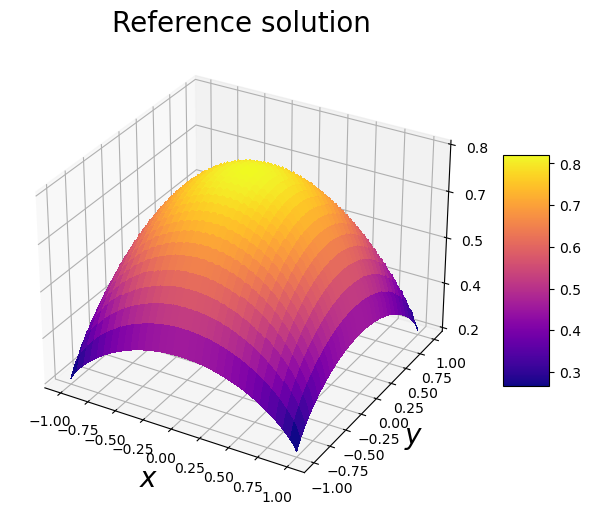

In [ ]:
font_format = {"family": "Times New Roman", "size": 20}

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, Y, avg_f, cmap="plasma", linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$y$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.show()

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


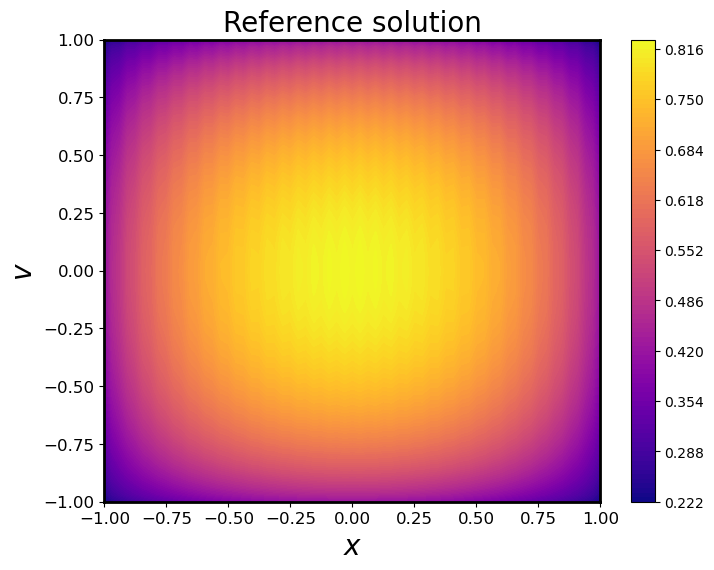

In [ ]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.contourf(X, Y, avg_f, 100, cmap="plasma")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

In [ ]:
# np.savez(
#     f"../data/rte2d_ex5_ref_{kn:.1e}.npz",
#     mesh_x=mesh_x,
#     mesh_y=mesh_y,
#     f=tensor_f,
#     rho=avg_f,
# )
kn

1.0

In [ ]:
# 边界条件检验代码示例
# 使用本文件实际变量命名：tensor_f, fn_l, fn_r, fn_b, fn_t, mesh_x, mesh_y, mesh_theta

# 检查左边界 x=mesh_x[0]
left_bc = tensor_f[0, :, :]  # (num_y+1, num_theta*4)
left_bc_true = jnp.zeros_like(mesh_y)  # (num_y+1,)
# 只检验每个y在所有角度的均值
left_bc_mean = np.mean(left_bc, axis=-1)
left_error = np.abs(left_bc_mean - left_bc_true)
print("左边界(x=%.2f)误差统计:" % mesh_x[0])
print("L2误差:", np.linalg.norm(left_error))
print("最大误差:", np.max(left_error))
print("平均误差:", np.mean(left_error))

# 检查右边界 x=mesh_x[-1]
right_bc = tensor_f[-1, :, :]  # (num_y+1, num_theta*4)
right_bc_true = jnp.zeros_like(mesh_y)  # (num_y+1,)
right_bc_mean = np.mean(right_bc, axis=-1)
right_error = np.abs(right_bc_mean - right_bc_true)
print("右边界(x=%.2f)误差统计:" % mesh_x[-1])
print("L2误差:", np.linalg.norm(right_error))
print("最大误差:", np.max(right_error))
print("平均误差:", np.mean(right_error))

# 检查下边界 y=mesh_y[0]
lower_bc = tensor_f[:, 0, :]  # (num_x+1, num_theta*4)
lower_bc_true = jnp.zeros_like(mesh_x)  # (num_x+1,)
lower_bc_mean = np.mean(lower_bc, axis=-1)
lower_error = np.abs(lower_bc_mean - lower_bc_true)
print("下边界(y=%.2f)误差统计:" % mesh_y[0])
print("L2误差:", np.linalg.norm(lower_error))
print("最大误差:", np.max(lower_error))
print("平均误差:", np.mean(lower_error))

# 检查上边界 y=mesh_y[-1]
upper_bc = tensor_f[:, -1, :]  # (num_x+1, num_theta*4)
upper_bc_true = jnp.zeros_like(mesh_x)  # (num_x+1,)
upper_bc_mean = np.mean(upper_bc, axis=-1)
upper_error = np.abs(upper_bc_mean - upper_bc_true)
print("上边界(y=%.2f)误差统计:" % mesh_y[-1])
print("L2误差:", np.linalg.norm(upper_error))
print("最大误差:", np.max(upper_error))
print("平均误差:", np.mean(upper_error))

左边界(x=-1.00)误差统计:
L2误差: 2.9142227
最大误差: 0.41345906
平均误差: 0.3574528
右边界(x=1.00)误差统计:
L2误差: 2.94379
最大误差: 0.4286281
平均误差: 0.36090478
下边界(y=-1.00)误差统计:
L2误差: 2.8831723
最大误差: 0.40917754
平均误差: 0.35362586
上边界(y=1.00)误差统计:
L2误差: 2.8831723
最大误差: 0.40917757
平均误差: 0.35362586


findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


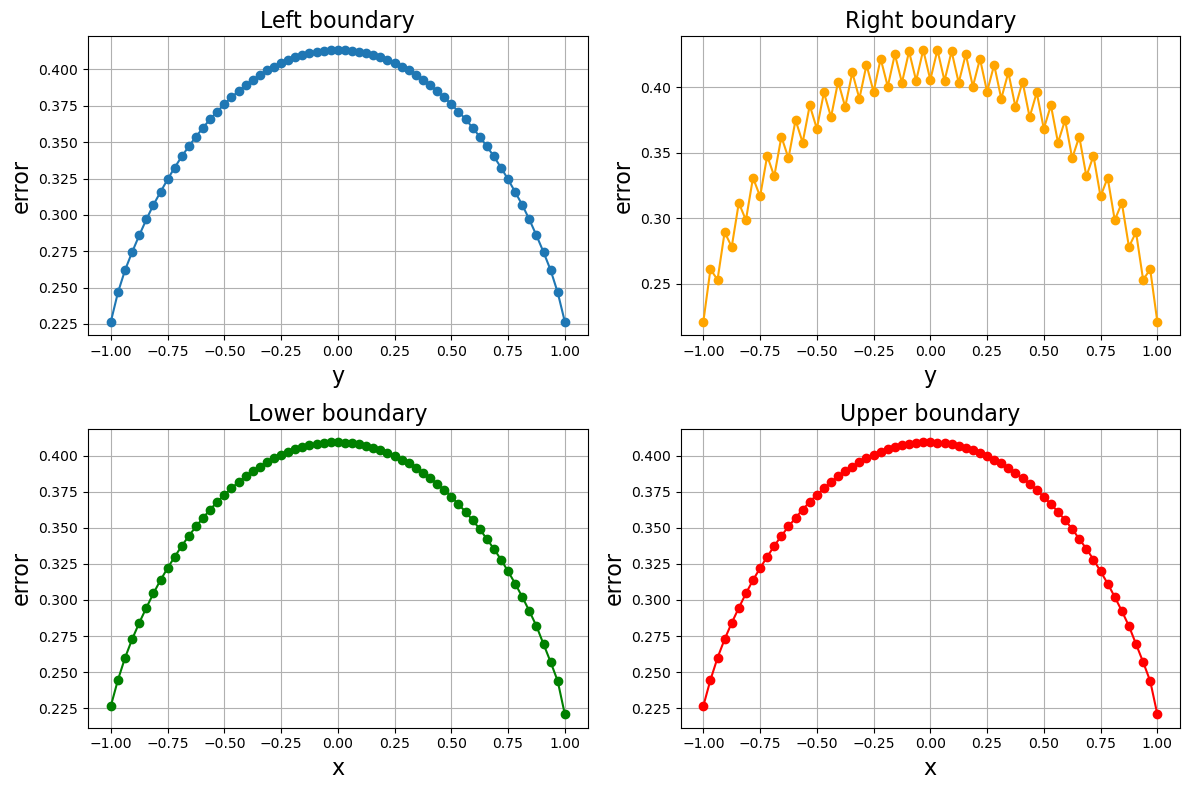

In [ ]:
# 边界条件误差可视化
import matplotlib.pyplot as plt

font_format = {"family": "Times New Roman", "size": 16}

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# 左边界
axs[0, 0].plot(mesh_y, left_error, marker="o")
axs[0, 0].set_title("Left boundary", fontdict=font_format)
axs[0, 0].set_xlabel("y", fontdict=font_format)
axs[0, 0].set_ylabel("error", fontdict=font_format)
axs[0, 0].grid(True)

# 右边界
axs[0, 1].plot(mesh_y, right_error, marker="o", color="orange")
axs[0, 1].set_title("Right boundary", fontdict=font_format)
axs[0, 1].set_xlabel("y", fontdict=font_format)
axs[0, 1].set_ylabel("error", fontdict=font_format)
axs[0, 1].grid(True)

# 下边界
axs[1, 0].plot(mesh_x, lower_error, marker="o", color="green")
axs[1, 0].set_title("Lower boundary", fontdict=font_format)
axs[1, 0].set_xlabel("x", fontdict=font_format)
axs[1, 0].set_ylabel("error", fontdict=font_format)
axs[1, 0].grid(True)

# 上边界
axs[1, 1].plot(mesh_x, upper_error, marker="o", color="red")
axs[1, 1].set_title("Upper boundary", fontdict=font_format)
axs[1, 1].set_xlabel("x", fontdict=font_format)
axs[1, 1].set_ylabel("error", fontdict=font_format)
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()